# Transfer Learning Pipeline — P. putida Fitness Prediction

This notebook demonstrates the omicsTL transfer learning pipeline using real fitness browser data, then uses the best model to:
- Predict fitness on held-out target data
- Explain predictions via SHAP (which conditions matter most)
- Recommend the most promising new conditions as a starting point for BacterAI

## Setup
| | Dataset | Strain | n | Response |
|---|---|---|---|---|
| **Source** | Fitness Browser (KT2440) | *P. putida* KT2440 (wild-type parent) | 261 | Mean gene fitness of pykA, pykF, ppc — robust z-score + sigmoid → 0–1 |
| **Target** | BacterAI experiment | PpJE3959 (engineered strain) | 198 | Whole-organism growth fitness (0–1) |

**Features (X):** 11 experimental conditions — d_glucose, sodium_citrate, sodium_octanoate, sodium_acetate, sodium_benzoate, d_xylose, l_arabinose, sodium_chloride, urea, ammonium_chloride, pH

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('always')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

import torch
from torch import device
import random

from omicstl.simulation_utils.data_utils import DatasetContainer
from omicstl.simulation_utils.model_utils import (
    fit_dl_model, fit_rf_model, predict_dl_model, predict_rf_model
)
from omicstl.r_utils import set_seed

plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})
sns.set_style('whitegrid')
shap.initjs()

## 2. Load Data

In [2]:
DATA_DIR = 'data/'

source_raw = pd.read_csv(DATA_DIR + 'pputida_source.csv')
target_raw = pd.read_csv(DATA_DIR + 'pputida_target.csv')

print(f'Source (KT2440)  : {source_raw.shape[0]} rows x {source_raw.shape[1]} columns')
print(f'Target (PpJE3959): {target_raw.shape[0]} rows x {target_raw.shape[1]} columns')
display(source_raw.head(3))
display(target_raw.head(3))

Source (KT2440)  : 261 rows x 16 columns
Target (PpJE3959): 198 rows x 26 columns


,SampleID,Resp,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,pH,fitness_pykA_PP_1362,fitness_pykF_PP_4301,fitness_ppc_PP_1505
0,set10IT006__Putida,0.523544,0.0,0,0,0.0,0,0,0,0,0,9.5,7.0,-0.116444,-0.058220,0.009629
1,set10IT008__Putida,0.426813,0.0,0,0,0.0,0,0,0,0,0,9.5,7.0,-0.823275,-0.007236,0.208178
2,set10IT010__Putida,0.611662,0.0,0,0,0.0,0,0,0,0,0,9.5,7.0,0.490549,-0.157503,-0.074934


,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,...,is_redo,round,experiment_number,feature,bad,parent_plate,strain,environment,fitness,depth
0,3.654529,3.486297,1.957007,3.676012,1.457999,2.330182,1.032274,94.663410,0.491145,0.818506,...,False,1,10,0.5321,0,Plate PpJE3959_1$8693513b52de46d470ad9398fa39b...,PpJE3959,aerobic_37deg,0.611086,122.567361
1,1.882782,1.647602,1.922884,1.910121,2.475156,2.609455,0.024642,190.842985,0.481353,0.312597,...,False,1,17,0.7370,0,Plate PpJE3959_2$a125cef5c93af3784aa0b483b1482...,PpJE3959,aerobic_37deg,0.604484,213.109578
2,0.893689,3.883286,1.295988,3.814129,1.637966,1.135892,0.140209,20.322280,0.214090,0.131588,...,False,1,52,0.7240,0,Plate PpJE3959_2$a125cef5c93af3784aa0b483b1482...,PpJE3959,aerobic_37deg,0.593821,42.469116


## 3. Prepare Datasets

Both source and target must share the same 11 feature columns and a `response` column.

Source : (261, 12)   response [0.017, 0.864]
Target : (198, 12)   response [-0.002, 0.611]


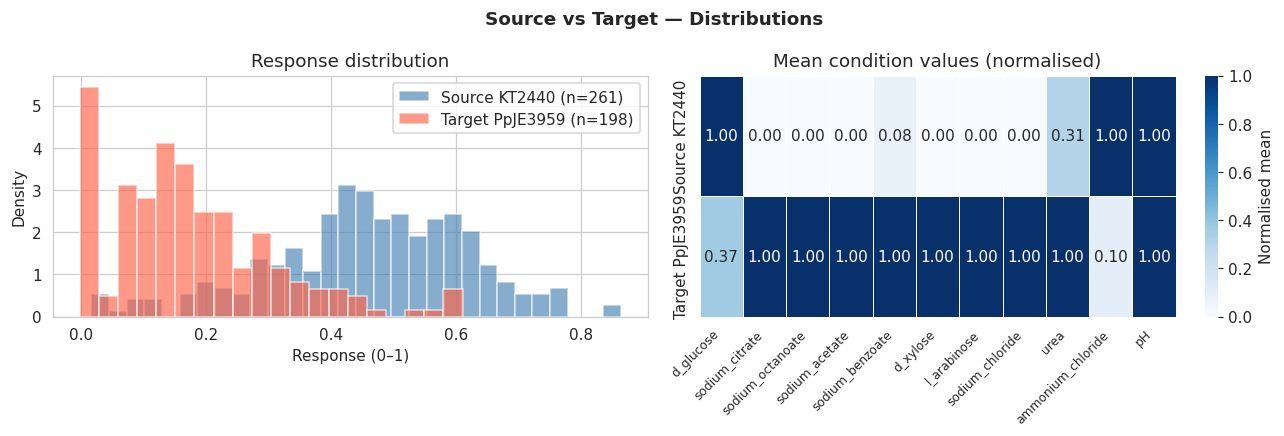

In [3]:
CONDITIONS = [
    'd_glucose', 'sodium_citrate', 'sodium_octanoate', 'sodium_acetate',
    'sodium_benzoate', 'd_xylose', 'l_arabinose', 'sodium_chloride',
    'urea', 'ammonium_chloride', 'pH'
]

source_data = source_raw[['Resp'] + CONDITIONS].rename(columns={'Resp': 'response'})
target_data = target_raw[['fitness'] + CONDITIONS].rename(columns={'fitness': 'response'})

print(f'Source : {source_data.shape}   response [{source_data.response.min():.3f}, {source_data.response.max():.3f}]')
print(f'Target : {target_data.shape}   response [{target_data.response.min():.3f}, {target_data.response.max():.3f}]')

# ── Response distribution overview ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Source vs Target — Distributions', fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(source_data.response, bins=30, alpha=0.65, color='steelblue', density=True,
        label=f'Source KT2440 (n={len(source_data)})')
ax.hist(target_data.response, bins=20, alpha=0.65, color='tomato', density=True,
        label=f'Target PpJE3959 (n={len(target_data)})')
ax.set(xlabel='Response (0–1)', ylabel='Density', title='Response distribution')
ax.legend()

ax = axes[1]
heat_df = pd.DataFrame([
    source_data[CONDITIONS].mean().rename('Source KT2440'),
    target_data[CONDITIONS].mean().rename('Target PpJE3959')
])
heat_norm = heat_df.div(heat_df.max(axis=0).replace(0, 1))
sns.heatmap(heat_norm, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Normalised mean'})
ax.set_title('Mean condition values (normalised)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Split Target into Train / Ensemble / Test

In [4]:
N_TRAIN, N_ENSEMBLE, N_TEST = 130, 18, 50

target_train_comb, target_test = train_test_split(
    target_data, train_size=N_TRAIN + N_ENSEMBLE, test_size=N_TEST, random_state=42
)
target_train, target_ensemble = train_test_split(
    target_train_comb, train_size=N_TRAIN, test_size=N_ENSEMBLE, random_state=42
)

print(f'Train: {len(target_train)}  |  Ensemble: {len(target_ensemble)}  |  Test: {len(target_test)}')

Train: 130  |  Ensemble: 18  |  Test: 50


## 5. Create DatasetContainer

In [5]:
datasets = DatasetContainer(
    source_data=source_data,
    target_data=target_train,
    target_ensemble_data=target_ensemble,
    target_test_data=[target_test]
)
datasets.set_response_column('response')
print('DatasetContainer ready.')

DatasetContainer ready.


## 6. Fit All Transfer Learning Models

In [6]:
param_grid = {
    'dropout':         [0.25, 0.5],
    'n_latent_dims':   [2],
    'hidden_dim_base': [6],
    'lr':              [0.01, 0.001],
    'source_epochs':   [1000],
    'target_epochs':   [1000],
    'freeze':          ['none'],
    'weight_decay':    [1e-4, 1e-2],
    'gamma':           [1, 2, 3]
}

In [7]:
# VAE
random.seed(42); torch.manual_seed(42)
vae_results, vae_model, _ = fit_dl_model(datasets, 'mult_vae', device('cpu'), param_grid)
print('VAE done'); display(vae_results)

VAE done


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1039: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1039: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_vae,mult_vae,target,0.125149,0.097884,NaN,NaN,...,0.50,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0001,2.0
1,None,None,test_0,mult_vae,mult_vae,target_nosource,0.124253,0.096077,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.0001,3.0


In [8]:
# MLP
random.seed(42); torch.manual_seed(42)
mlp_results, mlp_model, _ = fit_dl_model(datasets, 'mult_mlp', device('cpu'), param_grid)
print('MLP done'); display(mlp_results)

MLP done


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1039: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1039: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, test_results], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,...,dropout,hidden_dim_base,n_latent_dims,source_epochs,target_epochs,freeze,z_dim_base,lr,weight_decay,gamma
0,None,None,test_0,mult_mlp,mult_mlp,target,0.074480,0.061273,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.01,3.0
1,None,None,test_0,mult_mlp,mult_mlp,target_nosource,0.125285,0.097748,NaN,NaN,...,0.25,6.0,2.0,1000.0,1000.0,none,12.0,0.01,0.01,2.0


In [9]:
# Random Forest
random.seed(42); set_seed(42)
rf_results, rf_model = fit_rf_model(datasets)
print('RF done'); display(rf_results)

RF done


/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1237: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)
/workspaces/timed-hpc/src/omicstl/simulation_utils/model_utils.py:1237: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([test_row])], ignore_index=True)


,scenario,replicate,split,model,model_type,model_id,rmse,mae,acc,f1,mcc,precision,recall,roc_auc
0,None,None,test_0,rf,pred_source_full,target,0.402997,0.377418,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,test_0,rf,pred_source_full_val,target,0.402997,0.377418,NaN,NaN,NaN,NaN,NaN,NaN
2,None,None,test_0,rf,pred_0_full,target,0.059959,0.048288,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,test_0,rf,pred_0_full_val,target,0.059959,0.048288,NaN,NaN,NaN,NaN,NaN,NaN
4,None,None,test_0,rf,pred_1_full,target,0.062441,0.050619,NaN,NaN,NaN,NaN,NaN,NaN
5,None,None,test_0,rf,pred_1_full_val,target,0.062441,0.050619,NaN,NaN,NaN,NaN,NaN,NaN
6,None,None,test_0,rf,pred_2_full,target,0.060621,0.049146,NaN,NaN,NaN,NaN,NaN,NaN
7,None,None,test_0,rf,pred_2_full_val,target,0.060621,0.049146,NaN,NaN,NaN,NaN,NaN,NaN
8,None,None,test_0,rf,pred_3_full,target,0.060275,0.049916,NaN,NaN,NaN,NaN,NaN,NaN
9,None,None,test_0,rf,pred_3_full_val,target,0.060275,0.049916,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Select the Best Model

Compare RMSE on the test set across all models and automatically select the best.

In [10]:
# Extract transfer-learning test RMSE for each model
# DL models: model_id == 'target' row holds transfer-learning performance
# RF model:  pred_ensemble_full row holds the best ensemble prediction
def get_rmse(df, model_id):
    row = df[df['model_id'] == model_id]
    return float(row['rmse'].values[0]) if len(row) else np.inf

def get_rf_rmse(df):
    row = df[df['model_type'] == 'pred_ensemble_full']
    return float(row['rmse'].values[0]) if len(row) else np.inf

model_registry = {
    'VAE': {'rmse': get_rmse(vae_results, 'target'), 'model': vae_model, 'type': 'dl'},
    'MLP': {'rmse': get_rmse(mlp_results, 'target'), 'model': mlp_model, 'type': 'dl'},
    'RF':  {'rmse': get_rf_rmse(rf_results),          'model': rf_model,  'type': 'rf'},
}

best_name = min(model_registry, key=lambda k: model_registry[k]['rmse'])
best_info = model_registry[best_name]

print('Model RMSE comparison (test set):')
for name, info in model_registry.items():
    marker = '  <-- BEST' if name == best_name else ''
    print(f'  {name}: RMSE = {info["rmse"]:.4f}{marker}')

print(f'\nUsing {best_name} for predictions, SHAP, and recommendations.')

Model RMSE comparison (test set):
  VAE: RMSE = 0.1251
  MLP: RMSE = 0.0745
  RF: RMSE = 0.0603  <-- BEST

Using RF for predictions, SHAP, and recommendations.


## 8. Predict on Target Test Data

Check how well the best model tracks actual measured fitness on held-out target experiments.

Test set performance (RF):
  RMSE : 0.0602
  MAE  : 0.0494
  Pearson r : 0.8775


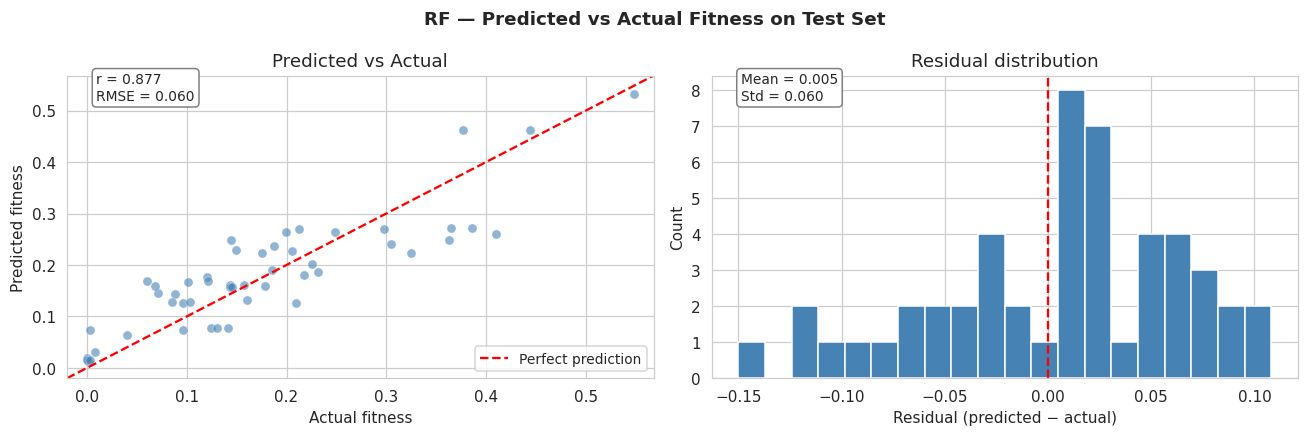

In [11]:
def predict(model_info, X):
    """Unified predict wrapper for DL and RF models."""
    X_df = pd.DataFrame(X, columns=CONDITIONS) if not isinstance(X, pd.DataFrame) else X[CONDITIONS]
    if model_info['type'] == 'dl':
        preds = predict_dl_model(model_info['model'], X_df)
        return np.array(preds, dtype=float).flatten()
    else:
        preds = predict_rf_model(model_info['model'], X_df)
        pred_df = pd.DataFrame(preds)
        col = 'pred_ensemble' if 'pred_ensemble' in pred_df.columns else pred_df.columns[-1]
        return pred_df[col].values.astype(float)

# Predict on test set
y_true = target_test['response'].values
y_pred = predict(best_info, target_test)

rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae  = np.mean(np.abs(y_true - y_pred))
r, _ = pearsonr(y_true, y_pred)

print(f'Test set performance ({best_name}):')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  Pearson r : {r:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{best_name} — Predicted vs Actual Fitness on Test Set', fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.4)
lim = [min(y_true.min(), y_pred.min()) - 0.02, max(y_true.max(), y_pred.max()) + 0.02]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set(xlabel='Actual fitness', ylabel='Predicted fitness', title='Predicted vs Actual', xlim=lim, ylim=lim)
ax.text(0.05, 0.92, f'r = {r:.3f}\nRMSE = {rmse:.3f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.legend(fontsize=9)

ax = axes[1]
residuals = y_pred - y_true
ax.hist(residuals, bins=20, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set(xlabel='Residual (predicted − actual)', ylabel='Count', title='Residual distribution')
ax.text(0.05, 0.92, f'Mean = {residuals.mean():.3f}\nStd = {residuals.std():.3f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

## 9. SHAP Analysis — Which Conditions Drive Fitness?

SHAP (SHapley Additive exPlanations) assigns each condition a contribution score for each prediction.
Positive SHAP = condition pushes fitness **up**; negative SHAP = condition pushes fitness **down**.

In [12]:
# Build a predict function that SHAP can call (numpy in → numpy out)
def shap_predict(X_array):
    X_df = pd.DataFrame(X_array, columns=CONDITIONS)
    return predict(best_info, X_df)

# Use target training data as background for KernelExplainer
# Summarise with k-means to keep it fast
background = shap.kmeans(target_train[CONDITIONS].values, 20)
explainer  = shap.KernelExplainer(shap_predict, background)

# Compute SHAP values on the full target dataset
print('Computing SHAP values on target data (this may take a few minutes)...')
shap_values = explainer.shap_values(target_data[CONDITIONS].values, nsamples=100)
print('Done.')

Computing SHAP values on target data (this may take a few minutes)...


  0%|          | 0/198 [00:00<?, ?it/s]

Done.


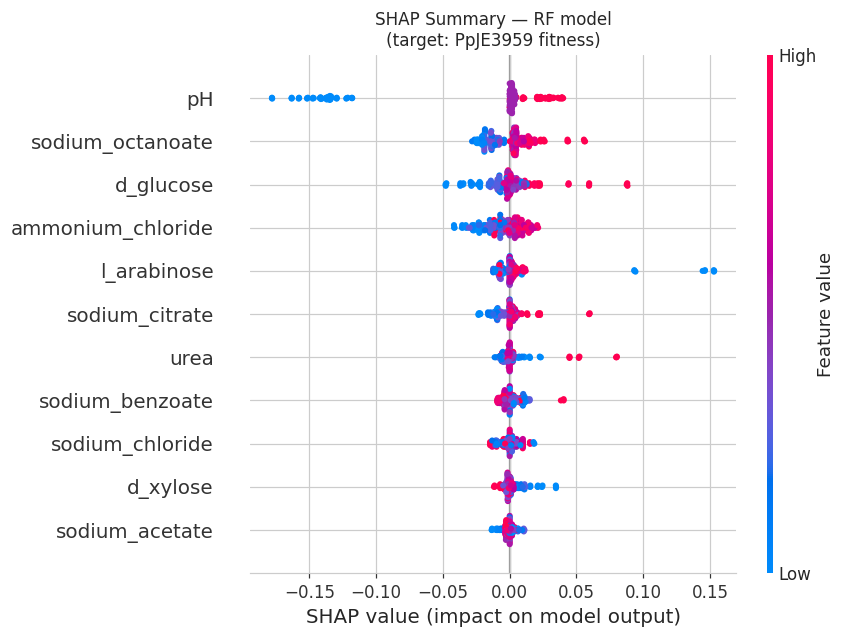

In [13]:
# ── Summary beeswarm plot ──────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values,
    target_data[CONDITIONS],
    feature_names=CONDITIONS,
    show=False
)
plt.title(f'SHAP Summary — {best_name} model\n(target: PpJE3959 fitness)', fontsize=11)
plt.tight_layout()
plt.show()

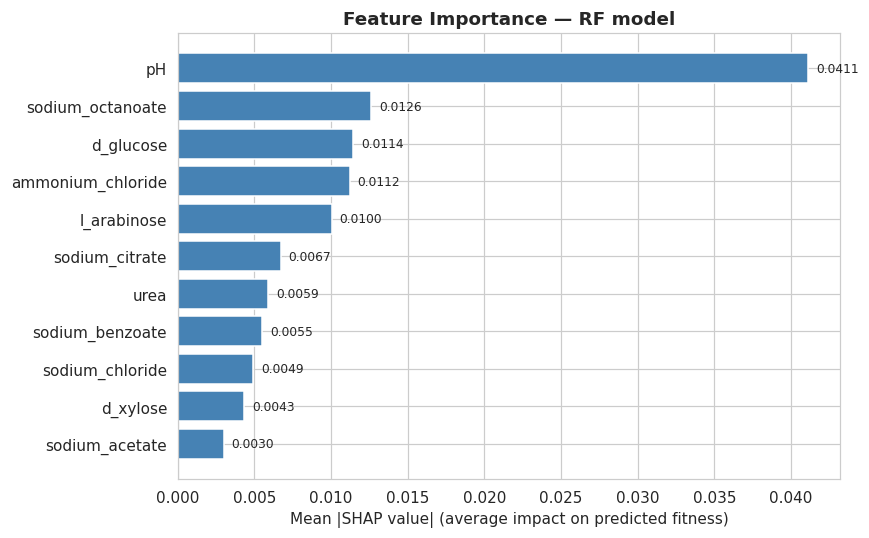

Condition importance ranking:
                   mean_|SHAP|
pH                     0.04114
sodium_octanoate       0.01262
d_glucose              0.01144
ammonium_chloride      0.01122
l_arabinose            0.01004
sodium_citrate         0.00673
urea                   0.00591
sodium_benzoate        0.00552
sodium_chloride        0.00493
d_xylose               0.00435
sodium_acetate         0.00299


In [14]:
# ── Mean |SHAP| bar chart — overall feature importance ───────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=CONDITIONS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values,
               color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (average impact on predicted fitness)')
ax.set_title(f'Feature Importance — {best_name} model', fontweight='bold')
for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Condition importance ranking:')
print(mean_abs_shap.sort_values(ascending=False).to_frame('mean_|SHAP|').round(5))

## 10. Identify Most Promising Conditions for BacterAI

Generate a large grid of new condition combinations, predict fitness for each, and return the top candidates.
These are conditions the model predicts will produce the **highest fitness** in PpJE3959 — the recommended starting point for the next BacterAI round.

In [15]:
np.random.seed(42)
N_GRID = 5000  # number of random condition combinations to evaluate

# Sample within the ranges observed in the target experiment
condition_ranges = {
    col: (target_data[col].min(), target_data[col].max())
    for col in CONDITIONS
}

print('Condition ranges (from target experiment):')
for col, (lo, hi) in condition_ranges.items():
    print(f'  {col:22s}: [{lo:.3f}, {hi:.3f}]')

Condition ranges (from target experiment):
  d_glucose             : [0.019, 3.983]
  sodium_citrate        : [0.038, 3.995]
  sodium_octanoate      : [0.015, 1.976]
  sodium_acetate        : [0.172, 11.935]
  sodium_benzoate       : [0.007, 2.475]
  d_xylose              : [0.011, 3.978]
  l_arabinose           : [0.025, 3.941]
  sodium_chloride       : [3.659, 247.123]
  urea                  : [0.005, 0.499]
  ammonium_chloride     : [0.008, 0.995]
  pH                    : [5.000, 9.000]


In [16]:
# Generate random grid using uniform sampling within each condition's range
grid = pd.DataFrame({
    col: np.random.uniform(lo, hi, N_GRID)
    for col, (lo, hi) in condition_ranges.items()
})

# Predict fitness for all grid points
print(f'Predicting fitness for {N_GRID:,} condition combinations...')
grid['predicted_fitness'] = predict(best_info, grid)
print('Done.')

print(f'\nPredicted fitness distribution across grid:')
print(grid['predicted_fitness'].describe().round(4))

Predicting fitness for 5,000 condition combinations...
Done.

Predicted fitness distribution across grid:
count    5000.0000
mean        0.1739
std         0.0715
min         0.0147
25%         0.1429
50%         0.1868
75%         0.2183
max         0.4110
Name: predicted_fitness, dtype: float64


In [17]:
# ── Top 20 recommended conditions ─────────────────────────────────────────────
TOP_N = 20
top_conditions = grid.nlargest(TOP_N, 'predicted_fitness').reset_index(drop=True)
top_conditions.index += 1  # 1-based rank

print(f'Top {TOP_N} recommended conditions for BacterAI (ranked by predicted fitness):')
display(top_conditions.round(4))

# Save recommendations
out_path = DATA_DIR + 'bacterai_recommendations.csv'
top_conditions.to_csv(out_path)
print(f'\nSaved -> {out_path}')

Top 20 recommended conditions for BacterAI (ranked by predicted fitness):


,d_glucose,sodium_citrate,sodium_octanoate,sodium_acetate,sodium_benzoate,d_xylose,l_arabinose,sodium_chloride,urea,ammonium_chloride,pH,predicted_fitness
1,3.7153,2.0282,1.9036,0.6446,0.7714,1.1677,0.1697,121.3579,0.4572,0.3177,8.9206,0.4110
2,0.5440,2.7843,1.8735,3.3348,0.4519,2.6218,0.0526,60.9142,0.0945,0.1831,8.6854,0.4026
3,0.6548,1.2186,1.6658,1.1407,1.9285,3.9221,0.0725,29.4247,0.4977,0.0397,8.0952,0.4007
4,1.2888,2.3055,1.6565,9.6803,1.0345,3.1743,0.0368,52.3307,0.2407,0.4106,8.7045,0.3949
5,3.6916,3.9252,1.7838,7.9376,1.6677,0.2705,0.0718,75.4217,0.4741,0.1332,7.2197,0.3948
6,3.7159,3.8794,1.2183,4.9984,0.3382,1.9046,0.0537,230.7381,0.4051,0.8680,8.7355,0.3928
7,0.9962,3.7321,1.1325,6.5408,0.7386,0.0659,0.0835,118.6207,0.4559,0.8419,8.5463,0.3893
8,3.5207,3.9767,1.9558,4.8868,0.9077,1.4098,0.1085,201.8352,0.0667,0.8907,7.5647,0.3852
9,1.6565,1.6916,1.5816,2.9424,0.3405,1.5806,0.1154,240.2194,0.0233,0.7624,8.4281,0.3850
10,2.0748,3.8879,1.6383,7.9620,2.2039,3.7573,0.1453,203.5135,0.3046,0.9271,8.8520,0.3843



Saved -> data/bacterai_recommendations.csv


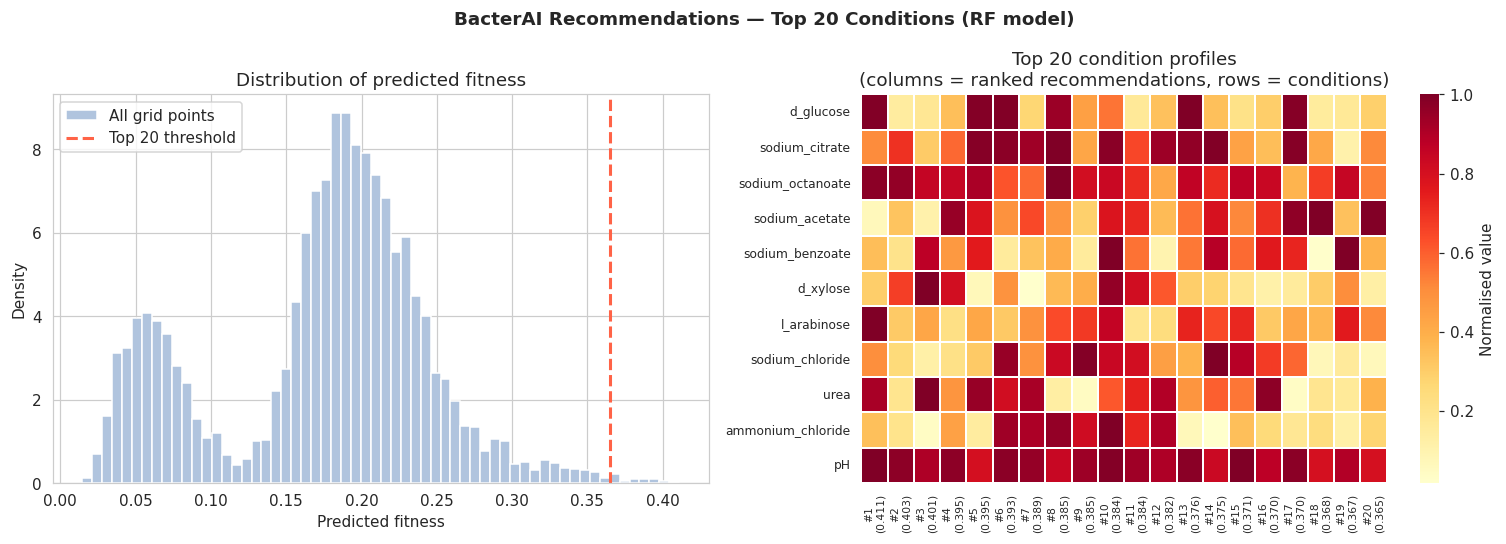

In [18]:
# ── Visualise top conditions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'BacterAI Recommendations — Top {TOP_N} Conditions ({best_name} model)',
             fontsize=12, fontweight='bold')

# Predicted fitness distribution: all grid vs top 20
ax = axes[0]
ax.hist(grid['predicted_fitness'], bins=60, color='lightsteelblue',
        edgecolor='white', density=True, label='All grid points')
ax.axvline(top_conditions['predicted_fitness'].min(), color='tomato',
           linestyle='--', lw=2, label=f'Top {TOP_N} threshold')
ax.set(xlabel='Predicted fitness', ylabel='Density',
       title='Distribution of predicted fitness')
ax.legend()

# Heatmap of top conditions (normalised)
ax = axes[1]
top_feat = top_conditions[CONDITIONS]
top_norm = top_feat.div(top_feat.max(axis=0).replace(0, 1))
sns.heatmap(
    top_norm.T, ax=ax, cmap='YlOrRd',
    xticklabels=[f'#{i}\n({v:.3f})' for i, v in
                 zip(top_conditions.index, top_conditions['predicted_fitness'])],
    yticklabels=CONDITIONS,
    linewidths=0.3, cbar_kws={'label': 'Normalised value'}
)
ax.set_title(f'Top {TOP_N} condition profiles\n(columns = ranked recommendations, rows = conditions)')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

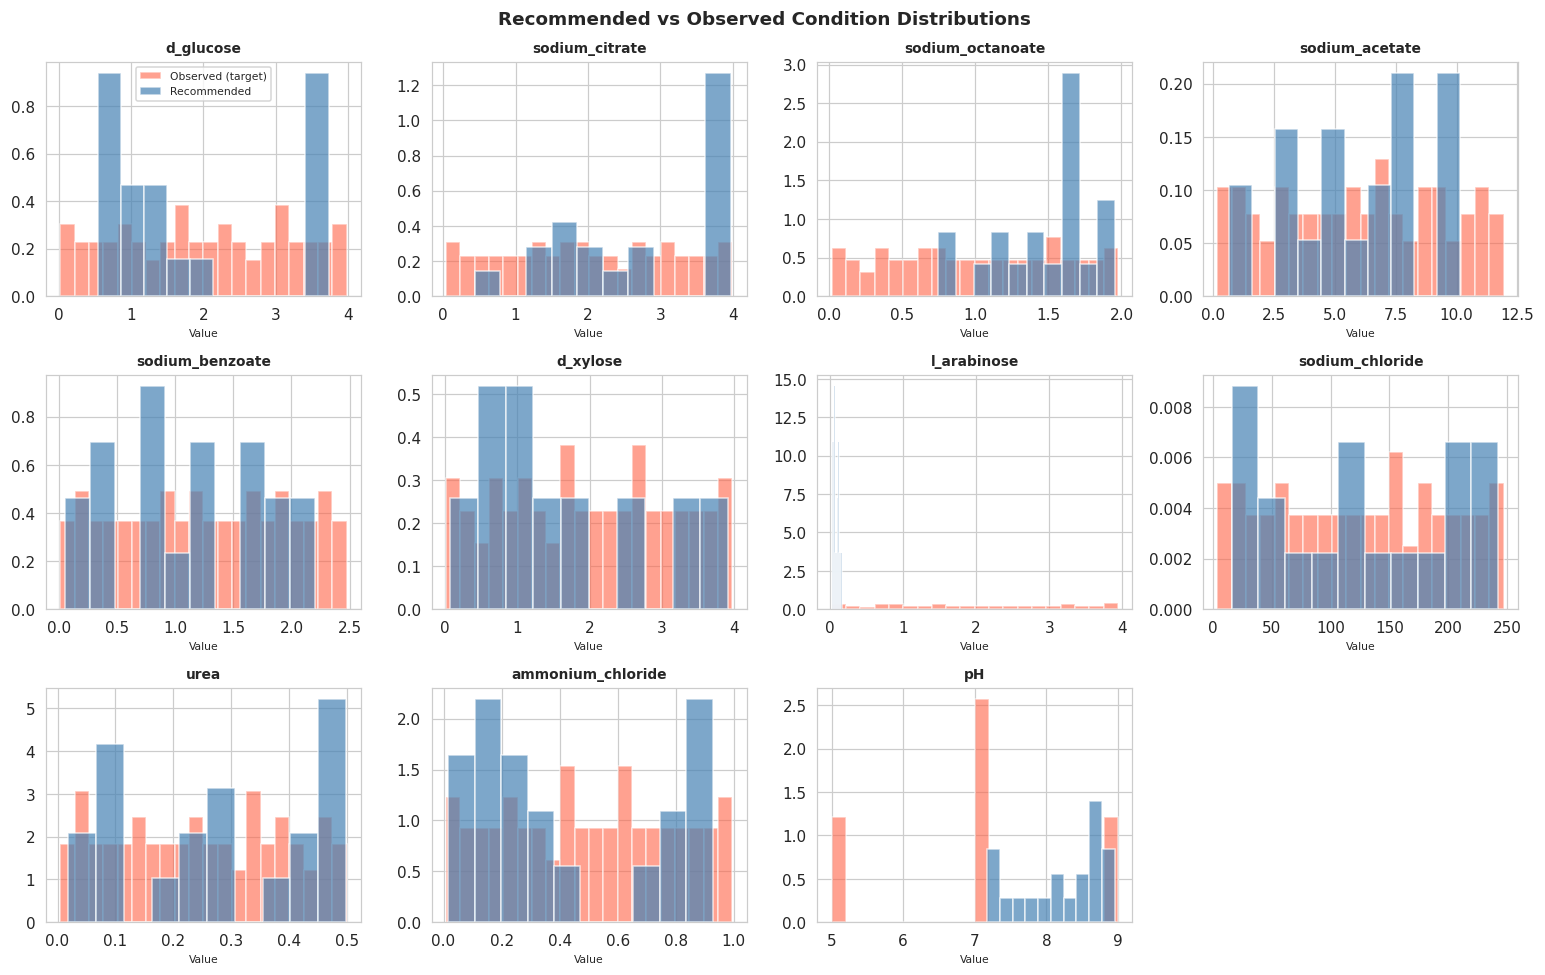

In [19]:
# ── Compare top recommended vs currently observed conditions ──────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Recommended vs Observed Condition Distributions', fontsize=12, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CONDITIONS):
    ax = axes[i]
    ax.hist(target_data[col], bins=20, alpha=0.6, color='tomato',
            density=True, label='Observed (target)')
    ax.hist(top_conditions[col], bins=10, alpha=0.7, color='steelblue',
            density=True, label='Recommended')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7)

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()